# Presentation Charts Recreated

Recreates chart files from `visualizations/01_*` through `visualizations/07_*` using Gold/Silver notebook summaries. Charts render inline in this notebook; no chart image files are written.


In [1]:
from pathlib import Path
import os
import warnings
warnings.filterwarnings("ignore")

_BOOT_ROOT = Path.cwd()
_MPL_DIR = (_BOOT_ROOT / "outputs" / ".matplotlib") if _BOOT_ROOT.name == "notebooks" else (_BOOT_ROOT / "notebooks" / "outputs" / ".matplotlib")
_MPL_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_MPL_DIR))
os.environ.setdefault("XDG_CACHE_HOME", str(_MPL_DIR.parent / ".cache"))

import numpy as np
import pandas as pd
import matplotlib
if os.environ.get("NOTEBOOK_VALIDATION") == "1":
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

try:
    from IPython.display import display, Markdown
except Exception:
    def display(x): print(x)
    def Markdown(x): return x

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.cwd().resolve()

SILVER = PROJECT_ROOT / "data" / "silver"
GOLD = PROJECT_ROOT / "data" / "gold"
LEGACY_OUT = PROJECT_ROOT / "EDA" / "outputs"
NB_OUT = PROJECT_ROOT / "notebooks" / "outputs"
CHART_OUT = NB_OUT / "charts"
NB_OUT.mkdir(parents=True, exist_ok=True)
CHART_OUT.mkdir(parents=True, exist_ok=True)

ANALYSIS_DATE = pd.Timestamp("2026-04-30", tz="UTC")
MARGIN = 0.40

TEAL = "#2DC4A2"
NAVY = "#1A2E44"
SLATE = "#4A6274"
ORANGE = "#F07D3E"
RED = "#E84545"
GOLD_C = "#F7B731"
LILAC = "#9B72CF"
LIGHT_BG = "#F8F9FA"
CAT_COLORS = [TEAL, NAVY, ORANGE, GOLD_C, SLATE, RED, LILAC]
plt.rcParams.update({
    "figure.facecolor": LIGHT_BG,
    "axes.facecolor": LIGHT_BG,
    "axes.edgecolor": "#E2E8ED",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#E2E8ED",
    "axes.labelcolor": NAVY,
    "axes.titlecolor": NAVY,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "xtick.color": SLATE,
    "ytick.color": SLATE,
    "legend.frameon": False,
    "font.family": ["DejaVu Sans"],
})

def money(x):
    return f"S${x:,.0f}"

def pct(x):
    return f"{x:.1%}"

RECREATED_CHARTS = []

def save_chart(fig, name):
    RECREATED_CHARTS.append(name)
    if os.environ.get("NOTEBOOK_VALIDATION") == "1":
        fig.canvas.draw()
    else:
        display(fig)
    plt.close(fig)
    print(f"rendered inline: {name}")
    return name

def load_marts():
    orders = pd.read_parquet(SILVER / "orders.parquet").copy()
    customers = pd.read_parquet(GOLD / "customers.parquet").copy()
    lines = pd.read_parquet(GOLD / "order_lines_enriched.parquet").copy()
    recharge_orders = pd.read_parquet(GOLD / "recharge_orders_enriched.parquet").copy()
    silver = {
        "discounts": pd.read_parquet(SILVER / "discounts.parquet"),
        "products": pd.read_parquet(SILVER / "products.parquet"),
        "campaigns": pd.read_parquet(SILVER / "campaigns.parquet"),
        "recharge_checkout": pd.read_parquet(SILVER / "recharge_checkout_items.parquet"),
        "recharge_recurring": pd.read_parquet(SILVER / "recharge_recurring_items.parquet"),
        "recharge_churned": pd.read_parquet(SILVER / "recharge_churned.parquet"),
        "recharge_reactivated": pd.read_parquet(SILVER / "recharge_reactivated.parquet"),
        "recharge_orders": pd.read_parquet(SILVER / "recharge_orders.parquet"),
    }
    orders["order_date"] = pd.to_datetime(orders["order_date"], utc=True)
    customers["first_order_date"] = pd.to_datetime(customers["first_order_date"], utc=True)
    customers["last_order_date"] = pd.to_datetime(customers["last_order_date"], utc=True)
    customers["second_order_date"] = pd.to_datetime(customers["second_order_date"], utc=True, errors="coerce")
    lines["order_date"] = pd.to_datetime(lines["order_date"], utc=True)

    orders["primary_revenue_sgd"] = pd.to_numeric(orders["order_revenue_sgd"], errors="coerce").fillna(0)
    orders["legacy_total_incl_shipping_sgd"] = pd.to_numeric(orders["order_total_incl_shipping_sgd"], errors="coerce").fillna(0)
    orders["Price: Total"] = orders["legacy_total_incl_shipping_sgd"]
    orders["Price: Total Discount"] = pd.to_numeric(orders["order_discount_sgd"], errors="coerce").fillna(0)
    orders["Price: Total Shipping"] = pd.to_numeric(orders["shipping_revenue_sgd"], errors="coerce").fillna(0)
    orders["revenue_basis_delta_sgd"] = orders["legacy_total_incl_shipping_sgd"] - orders["primary_revenue_sgd"]

    customers["total_revenue"] = pd.to_numeric(customers["total_revenue_sgd"], errors="coerce").fillna(0)
    customers["total_discount"] = pd.to_numeric(customers["total_discount_sgd"], errors="coerce").fillna(0)
    customers["first_product_cat"] = customers["first_product_category"]
    customers["is_repeat"] = customers["is_repeat"].astype(bool)

    for col in ["Line: Quantity", "Line: Price", "Line: Discount", "Line: Total"]:
        if col in lines.columns:
            lines[col] = pd.to_numeric(lines[col], errors="coerce").fillna(0)
    return orders, customers, lines, recharge_orders, silver

orders, customers, lines, recharge_orders, silver = load_marts()
print(f"Loaded marts: {len(orders):,} orders, {len(customers):,} customers, {len(lines):,} enriched lines")
print("Primary revenue excludes shipping. Legacy comparability uses order_total_incl_shipping_sgd.")


Loaded marts: 27,350 orders, 13,780 customers, 50,963 enriched lines
Primary revenue excludes shipping. Legacy comparability uses order_total_incl_shipping_sgd.


## Build Shared Summaries


In [2]:
annual = orders.assign(year=orders.order_date.dt.year).groupby("year").agg(orders=("order_id", "count"), customers=("customer_id", "nunique"), revenue_sgd=("primary_revenue_sgd", "sum"), legacy_revenue_sgd=("legacy_total_incl_shipping_sgd", "sum"), discount_sgd=("Price: Total Discount", "sum"), discount_orders=("has_discount", "sum")).assign(disc_pct_orders=lambda d: d.discount_orders / d.orders)
monthly = orders.assign(month=orders.order_date.dt.to_period("M").dt.to_timestamp()).groupby("month").agg(revenue=("primary_revenue_sgd", "sum"), orders=("order_id", "count")).reset_index()
channel_quality = customers.groupby("first_channel").agg(customers=("customer_id", "count"), repeaters=("is_repeat", "sum"), avg_ltv=("total_revenue", "mean"), avg_orders=("total_orders", "mean"), pct_subscribed=("ever_subscribed", "mean")).assign(repeat_rate=lambda d: d.repeaters / d.customers).reset_index()
cat_per_cust = lines.groupby("customer_id")["product_category"].nunique().clip(upper=4).reset_index().rename(columns={"product_category":"n_categories"})
cat_per_cust["category_label"] = cat_per_cust.n_categories.map({1:"1 product",2:"2 products",3:"3 products",4:"4+ products"})
cross = customers.merge(cat_per_cust, on="customer_id", how="left"); cross["category_label"] = cross.category_label.fillna("1 product")
cross_summary = cross.groupby("category_label").agg(customers=("customer_id", "count"), repeat_rate=("is_repeat", "mean"), avg_ltv=("total_revenue", "mean")).reindex(["1 product","2 products","3 products","4+ products"]).reset_index()
first_order = orders.sort_values("order_date").groupby("customer_id").first().reset_index()[["customer_id", "Price: Total Discount", "primary_revenue_sgd"]]
disc_df = customers.merge(first_order, on="customer_id", how="left")
disc_df["disc_depth"] = (disc_df["Price: Total Discount"].fillna(0) / disc_df.primary_revenue_sgd.replace(0, np.nan)).fillna(0).clip(0,1)
disc_df["discount_bin"] = pd.cut(disc_df.disc_depth, [-.001,0,.05,.10,.20,.30,.50,1.01], labels=["Full price","1-5% off","6-10% off","11-20% off","21-30% off","31-50% off","51%+ off"])
depth = disc_df.groupby("discount_bin", observed=True).agg(customers=("customer_id", "count"), repeat_rate=("is_repeat", "mean"), avg_ltv=("total_revenue", "mean")).reset_index()
print("shared summaries ready")


shared summaries ready


## Revenue and Volume Charts


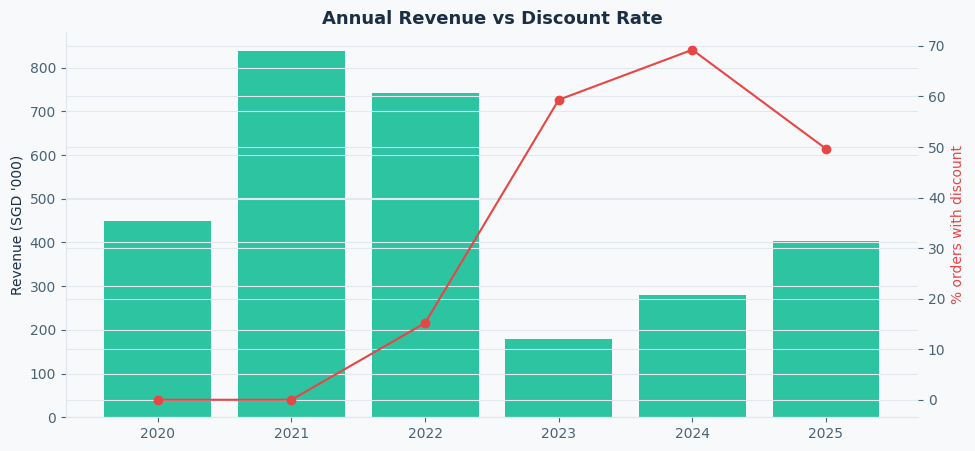

rendered inline: 01a_revenue_discount_trend


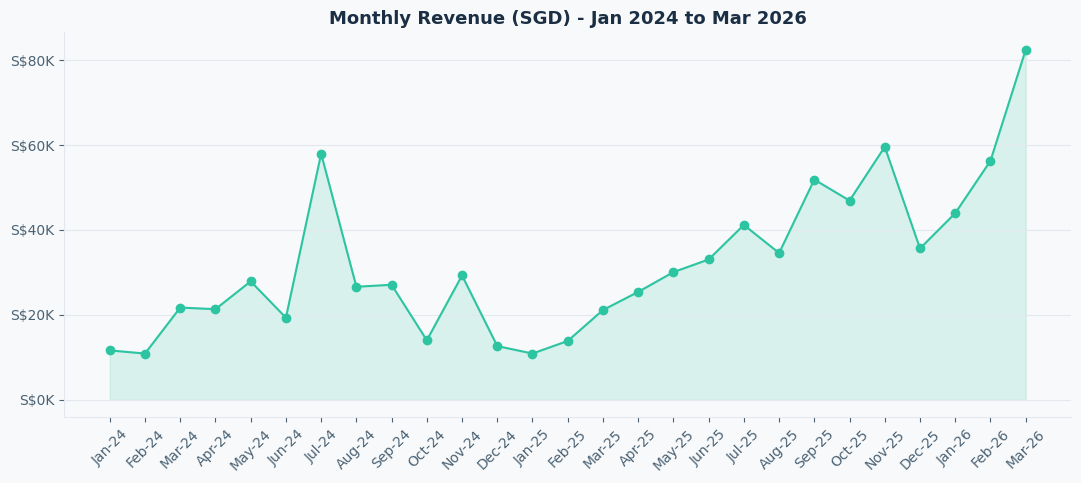

rendered inline: 01b_monthly_revenue_2024_2026


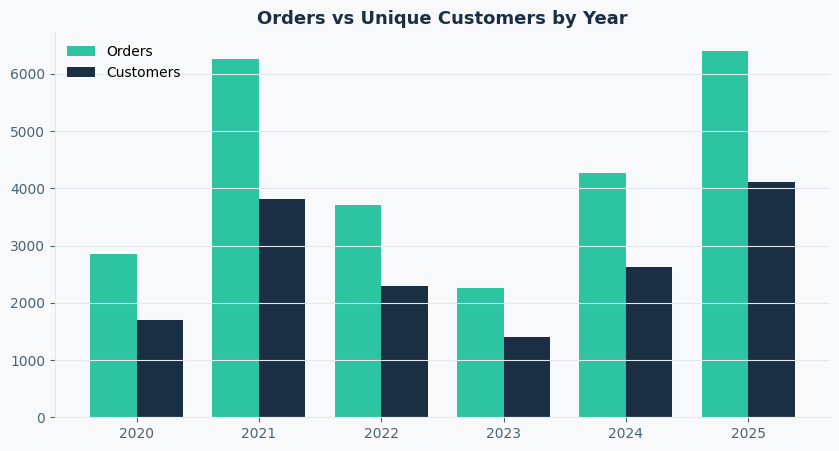

rendered inline: 01c_orders_customers_by_year


'01c_orders_customers_by_year'

In [3]:
a = annual.loc[(annual.index >= 2020) & (annual.index <= 2025)].reset_index()
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(a.year.astype(str), a.revenue_sgd/1000, color=TEAL)
ax1.set_title("Annual Revenue vs Discount Rate")
ax1.set_ylabel("Revenue (SGD '000)")
ax2 = ax1.twinx(); ax2.plot(a.year.astype(str), a.disc_pct_orders*100, color=RED, marker="o"); ax2.set_ylabel("% orders with discount", color=RED)
save_chart(fig, "01a_revenue_discount_trend")

m = monthly[(monthly.month >= "2024-01-01") & (monthly.month <= "2026-03-31")]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(m.month.dt.strftime("%b-%y"), m.revenue, color=TEAL, marker="o")
ax.fill_between(range(len(m)), m.revenue, color=TEAL, alpha=.15)
ax.set_title("Monthly Revenue (SGD) - Jan 2024 to Mar 2026")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"S${v/1000:.0f}K"))
save_chart(fig, "01b_monthly_revenue_2024_2026")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(a)); w=.38
ax.bar(x-w/2, a.orders, width=w, color=TEAL, label="Orders")
ax.bar(x+w/2, a.customers, width=w, color=NAVY, label="Customers")
ax.set_xticks(x); ax.set_xticklabels(a.year.astype(str)); ax.legend(); ax.set_title("Orders vs Unique Customers by Year")
save_chart(fig, "01c_orders_customers_by_year")


## Retention, Product, Subscription, and Discount Charts


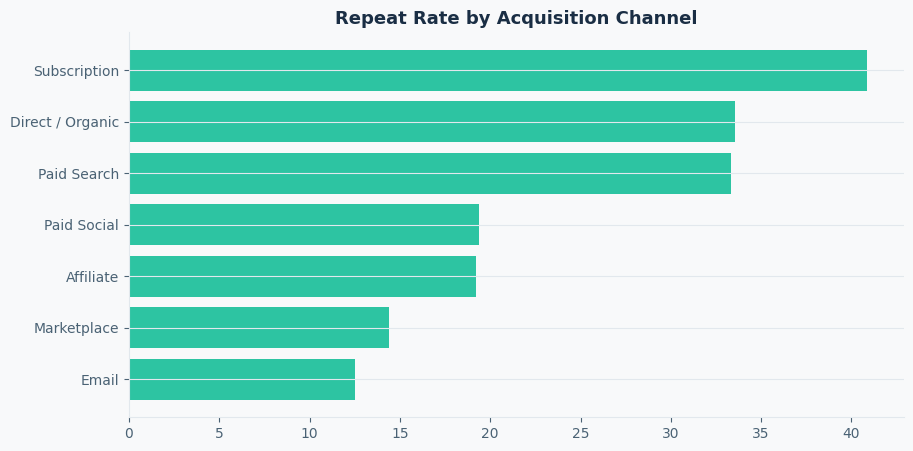

rendered inline: 02a_retention_by_channel


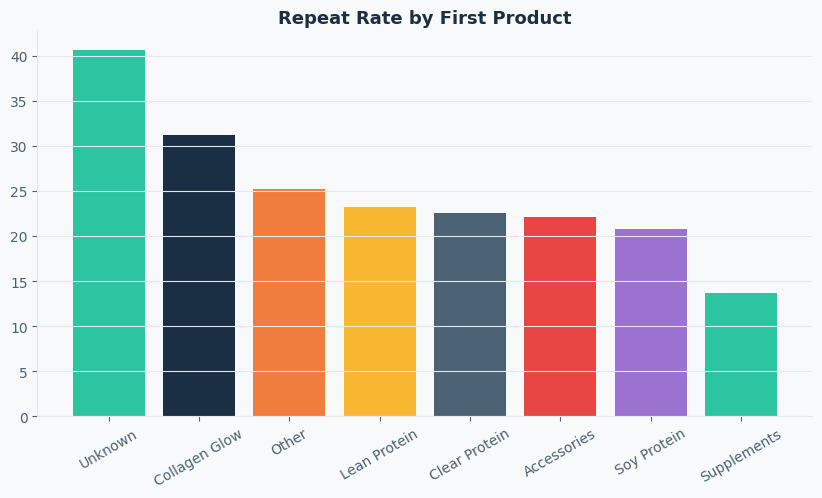

rendered inline: 02b_retention_by_product


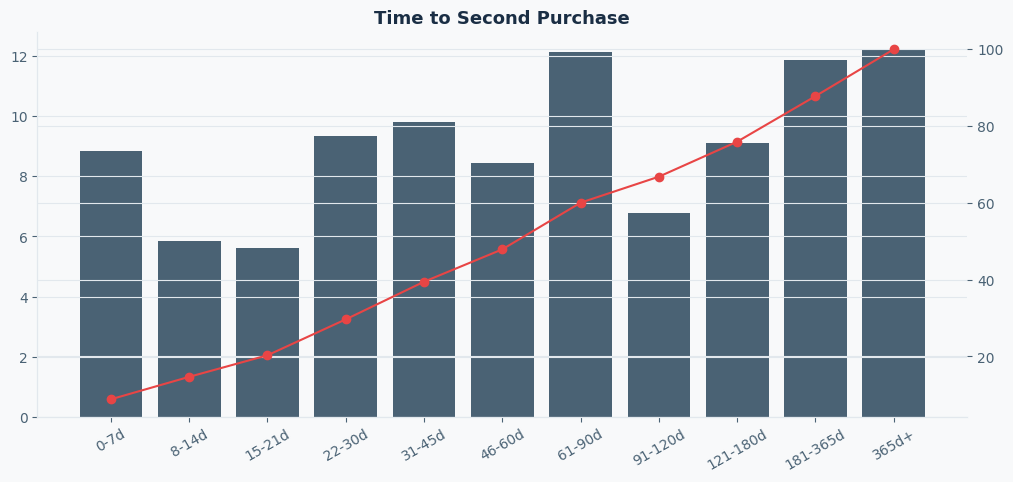

rendered inline: 02c_time_to_second_purchase


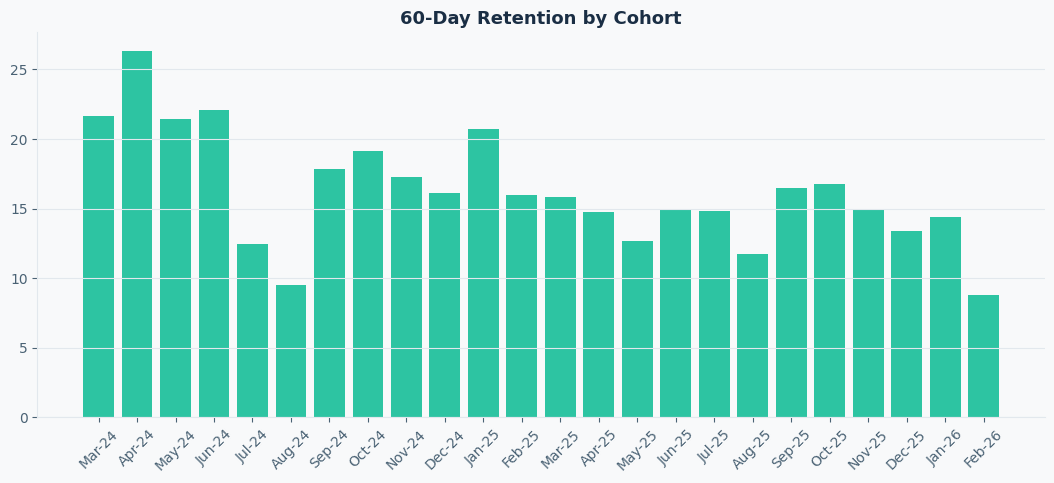

rendered inline: 02d_cohort_60d_retention


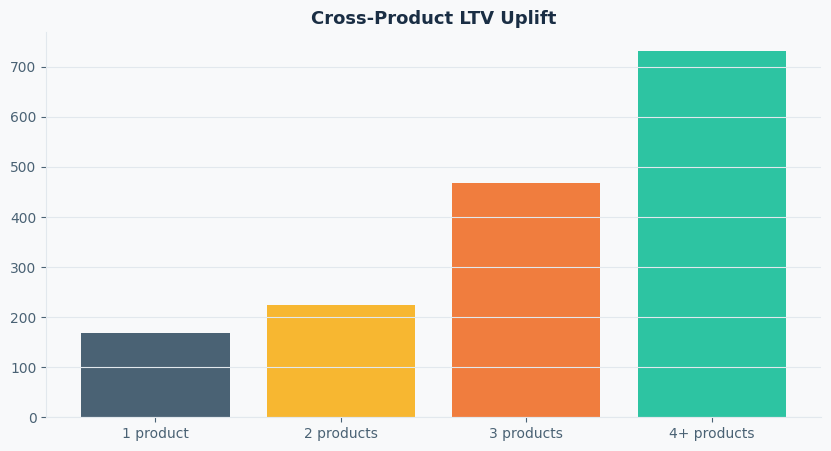

rendered inline: 03a_cross_product_ltv


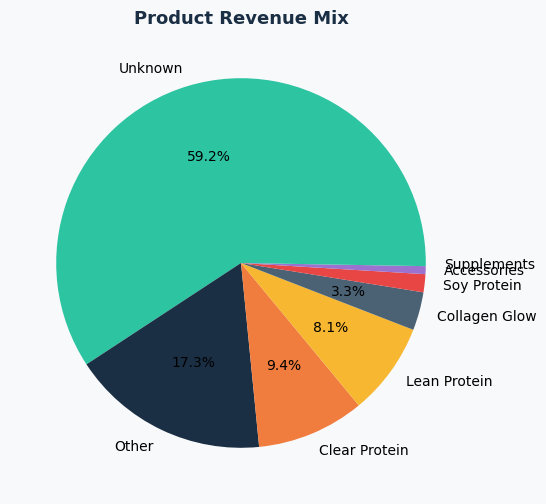

rendered inline: 03b_product_revenue_mix


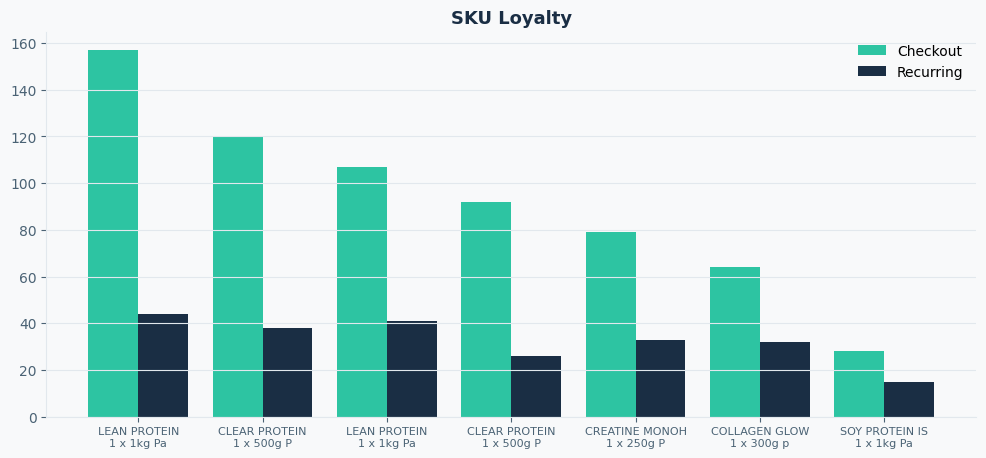

rendered inline: 03c_sku_loyalty


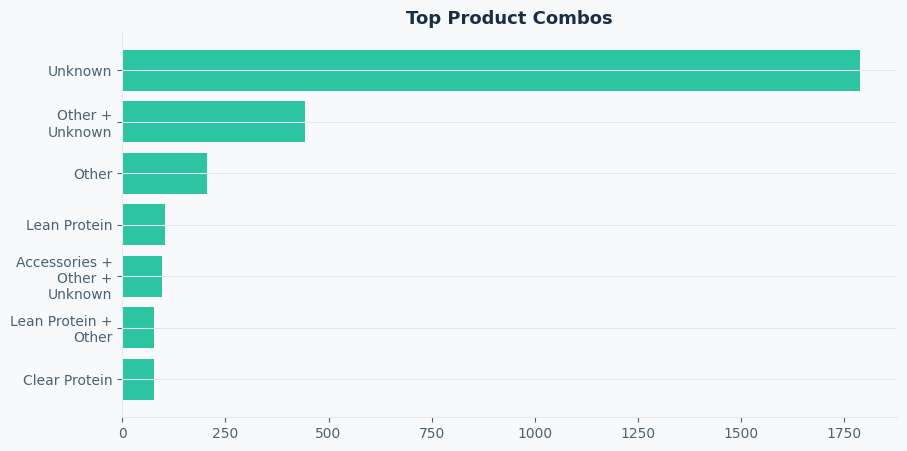

rendered inline: 03d_top_product_combos


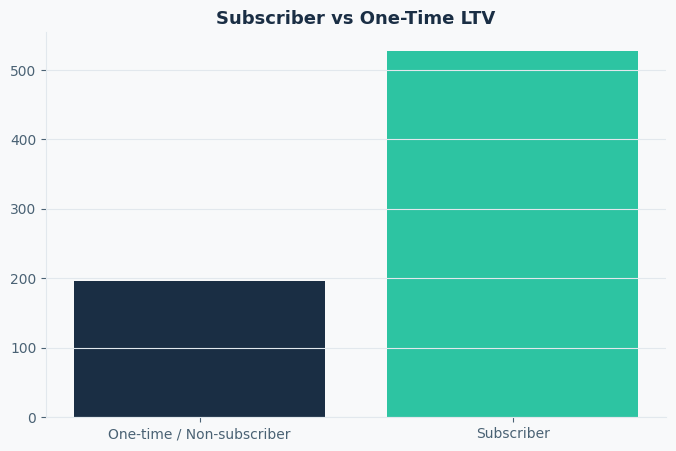

rendered inline: 04a_subscriber_vs_onetime


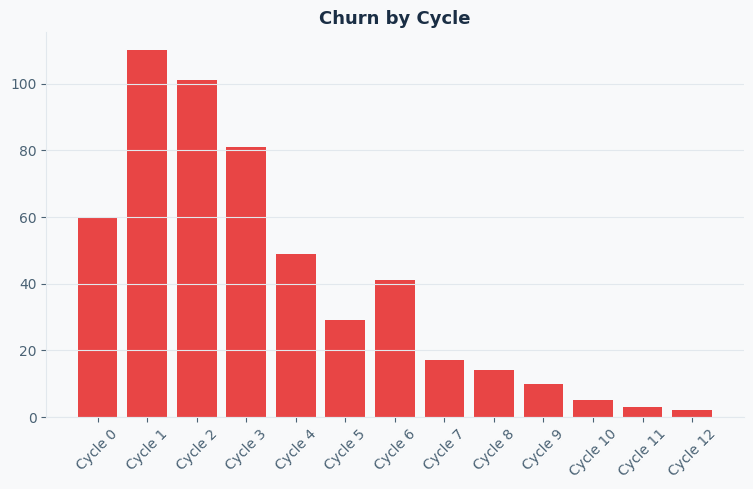

rendered inline: 04b_churn_by_cycle


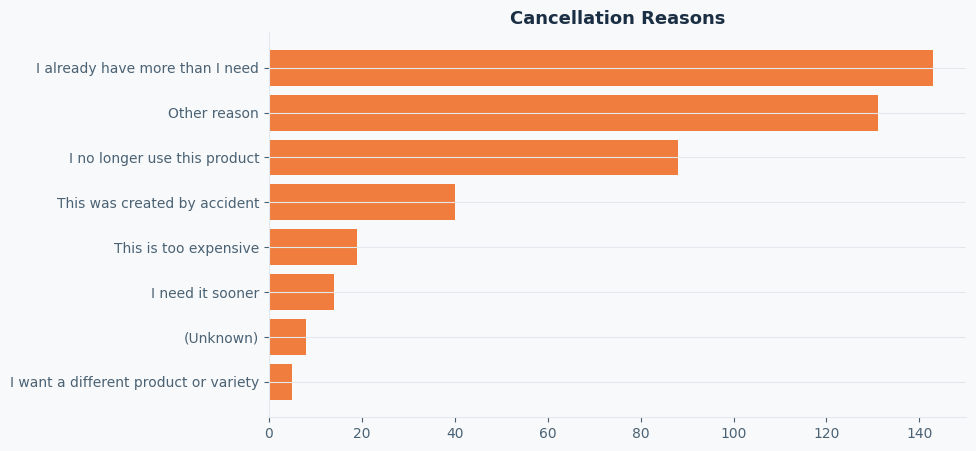

rendered inline: 04c_cancellation_reasons


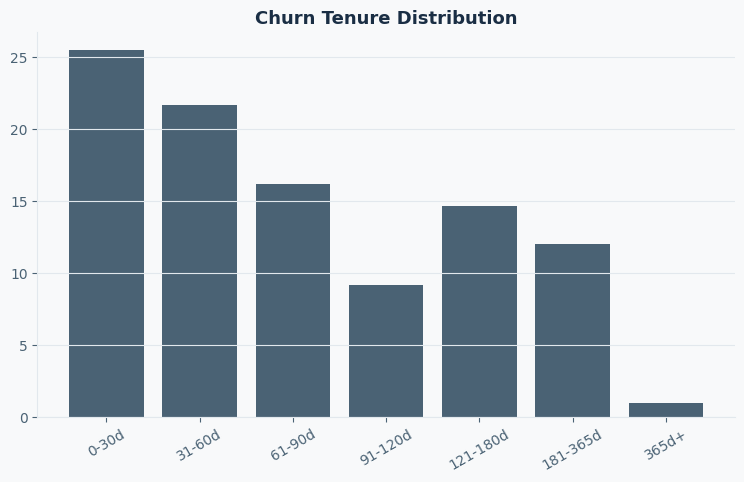

rendered inline: 04d_churn_tenure_distribution


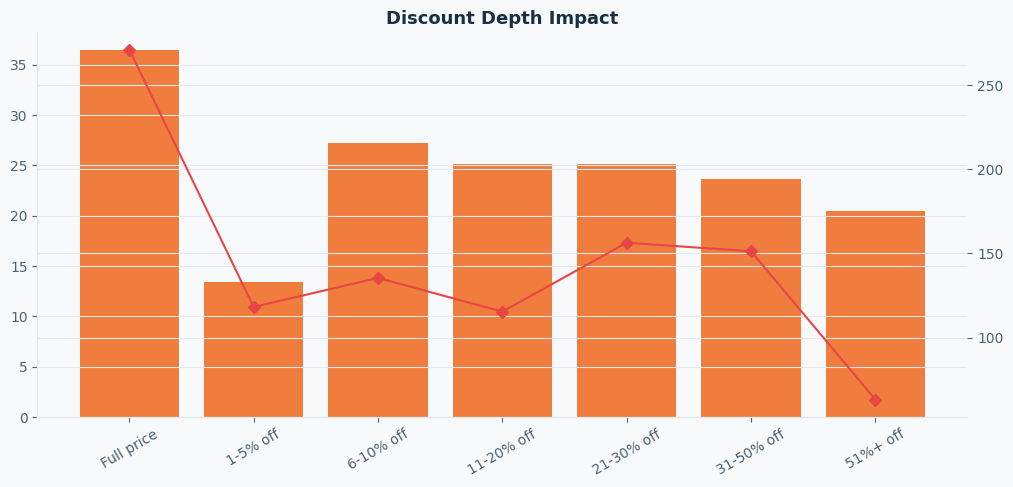

rendered inline: 05a_discount_depth_impact


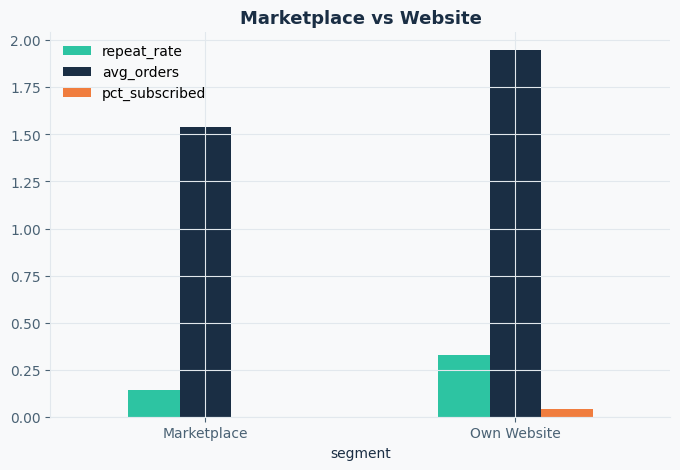

rendered inline: 05b_marketplace_vs_website


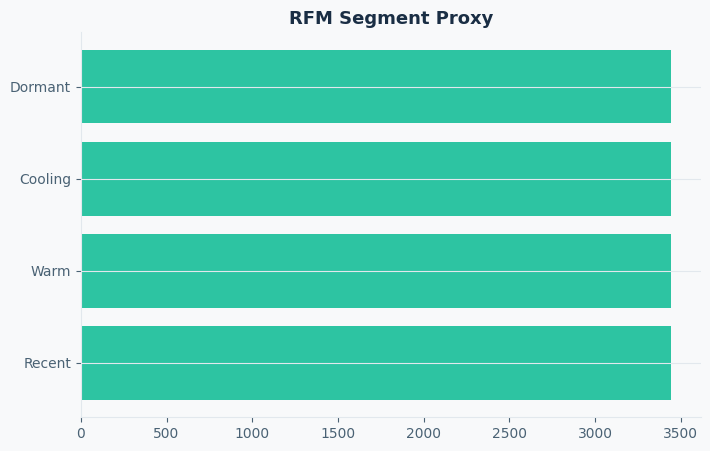

rendered inline: 05c_rfm_segments


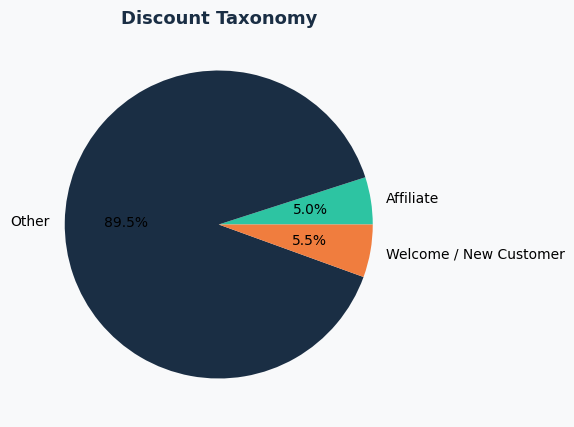

rendered inline: 05d_discount_code_taxonomy


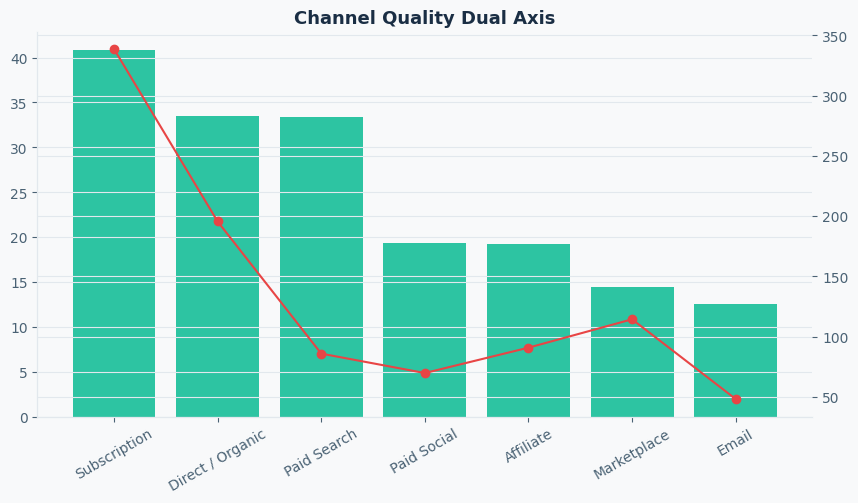

rendered inline: 06a_channel_quality_dual


'06a_channel_quality_dual'

In [4]:
fig, ax = plt.subplots(figsize=(10,5)); cq=channel_quality.sort_values("repeat_rate"); ax.barh(cq.first_channel, cq.repeat_rate*100, color=TEAL); ax.set_title("Repeat Rate by Acquisition Channel"); save_chart(fig,"02a_retention_by_channel")
prod = customers.groupby("first_product_cat").is_repeat.mean().sort_values(ascending=False).head(8).reset_index()
fig, ax = plt.subplots(figsize=(10,5)); ax.bar(prod.first_product_cat, prod.is_repeat*100, color=CAT_COLORS[:len(prod)]); ax.tick_params(axis="x", rotation=30); ax.set_title("Repeat Rate by First Product"); save_chart(fig,"02b_retention_by_product")
rep = customers[customers.is_repeat].copy(); rep["bucket"] = pd.cut(rep.days_to_second, [0,7,14,21,30,45,60,90,120,180,365,99999], labels=["0-7d","8-14d","15-21d","22-30d","31-45d","46-60d","61-90d","91-120d","121-180d","181-365d","365d+"])
t2 = rep.bucket.value_counts().reindex(rep.bucket.cat.categories).reset_index(); t2.columns=["bucket","n"]; t2["pct"] = t2.n/t2.n.sum(); t2["cum"] = t2.pct.cumsum()
fig, ax = plt.subplots(figsize=(12,5)); ax.bar(t2.bucket.astype(str), t2.pct*100, color=SLATE); ax2=ax.twinx(); ax2.plot(t2.bucket.astype(str), t2.cum*100, color=RED, marker="o"); ax.tick_params(axis="x", rotation=30); ax.set_title("Time to Second Purchase"); save_chart(fig,"02c_time_to_second_purchase")
cohort = customers.copy(); cohort["cohort_month"] = cohort.first_order_date.dt.to_period("M").astype(str); eligible=cohort[cohort.first_order_date <= ANALYSIS_DATE-pd.Timedelta(days=60)].copy(); eligible["repeat60"] = eligible.is_repeat & (eligible.days_to_second.fillna(9999)<=60); cr=eligible.groupby("cohort_month").agg(retention=("repeat60","mean"), size=("customer_id","count")).tail(24).reset_index()
fig, ax = plt.subplots(figsize=(13,5)); ax.bar(pd.to_datetime(cr.cohort_month).dt.strftime("%b-%y"), cr.retention*100, color=TEAL); ax.tick_params(axis="x", rotation=45); ax.set_title("60-Day Retention by Cohort"); save_chart(fig,"02d_cohort_60d_retention")

fig, ax = plt.subplots(figsize=(10,5)); ax.bar(cross_summary.category_label, cross_summary.avg_ltv, color=[SLATE,GOLD_C,ORANGE,TEAL]); ax.set_title("Cross-Product LTV Uplift"); save_chart(fig,"03a_cross_product_ltv")
prod_rev = lines.groupby("product_category")["Line: Total"].sum().sort_values(ascending=False).head(8)
fig, ax = plt.subplots(figsize=(8,6)); ax.pie(prod_rev, labels=prod_rev.index, autopct=lambda p:f"{p:.1f}%" if p>3 else "", colors=CAT_COLORS); ax.set_title("Product Revenue Mix"); save_chart(fig,"03b_product_revenue_mix")
rc_checkout=silver["recharge_checkout"]; rc_recurring=silver["recharge_recurring"]; co=rc_checkout.groupby(["product_title","variant_title"]).customer_id.nunique().rename("checkout"); re=rc_recurring.groupby(["product_title","variant_title"]).customer_id.nunique().rename("recurring"); loy=pd.concat([co,re],axis=1).dropna().sort_values("checkout",ascending=False).head(7).reset_index(); loy["label"]=loy.product_title.str.slice(0,14)+"\n"+loy.variant_title.astype(str).str.slice(0,10)
fig, ax=plt.subplots(figsize=(12,5)); x=np.arange(len(loy)); ax.bar(x-.2,loy.checkout,width=.4,color=TEAL,label="Checkout"); ax.bar(x+.2,loy.recurring,width=.4,color=NAVY,label="Recurring"); ax.set_xticks(x); ax.set_xticklabels(loy.label,fontsize=8); ax.legend(); ax.set_title("SKU Loyalty"); save_chart(fig,"03c_sku_loyalty")
combos=lines[lines.customer_id.isin(set(customers[customers.is_repeat].customer_id))].groupby("customer_id").product_category.apply(lambda s:" + ".join(sorted(s.dropna().unique()))).value_counts().head(7)
fig, ax=plt.subplots(figsize=(10,5)); ax.barh([c.replace(" + "," +\n") for c in combos.index[::-1]], combos.values[::-1], color=TEAL); ax.set_title("Top Product Combos"); save_chart(fig,"03d_top_product_combos")

sv=customers.groupby("ever_subscribed").total_revenue.mean().rename(index={False:"One-time / Non-subscriber", True:"Subscriber"})
fig, ax=plt.subplots(figsize=(8,5)); ax.bar(sv.index, sv.values, color=[NAVY,TEAL]); ax.set_title("Subscriber vs One-Time LTV"); save_chart(fig,"04a_subscriber_vs_onetime")
ch=silver["recharge_churned"].copy(); ch["subscription_activation_date"]=pd.to_datetime(ch.subscription_activation_date,errors="coerce"); ch["subscription_churn_date"]=pd.to_datetime(ch.subscription_churn_date,errors="coerce"); ch["tenure_days"]=(ch.subscription_churn_date-ch.subscription_activation_date).dt.days; ch["cycle"]=(ch.tenure_days/30).fillna(0).clip(lower=0).round().astype(int); cyc=ch.cycle.value_counts().sort_index().head(13)
fig, ax=plt.subplots(figsize=(9,5)); ax.bar([f"Cycle {i}" for i in cyc.index], cyc.values, color=RED); ax.tick_params(axis="x",rotation=45); ax.set_title("Churn by Cycle"); save_chart(fig,"04b_churn_by_cycle")
rea=ch.cancellation_reason.value_counts().head(8).sort_values(); fig, ax=plt.subplots(figsize=(9,5)); ax.barh(rea.index.astype(str), rea.values, color=ORANGE); ax.set_title("Cancellation Reasons"); save_chart(fig,"04c_cancellation_reasons")
ten=pd.cut(ch.tenure_days,[0,30,60,90,120,180,365,9999],labels=["0-30d","31-60d","61-90d","91-120d","121-180d","181-365d","365d+"]).value_counts().sort_index(); fig, ax=plt.subplots(figsize=(9,5)); ax.bar(ten.index.astype(str), ten.values/ten.sum()*100, color=SLATE); ax.tick_params(axis="x",rotation=30); ax.set_title("Churn Tenure Distribution"); save_chart(fig,"04d_churn_tenure_distribution")

fig, ax=plt.subplots(figsize=(12,5)); ax.bar(depth.discount_bin.astype(str), depth.repeat_rate*100, color=ORANGE); ax2=ax.twinx(); ax2.plot(depth.discount_bin.astype(str), depth.avg_ltv, color=RED, marker="D"); ax.tick_params(axis="x", rotation=30); ax.set_title("Discount Depth Impact"); save_chart(fig,"05a_discount_depth_impact")
fig, ax=plt.subplots(figsize=(8,5)); mc=customers.assign(segment=np.where(customers.first_channel.eq("Marketplace"),"Marketplace",np.where(customers.first_channel.isin(["Direct / Organic","Paid Social","Paid Search","Email","Affiliate"]),"Own Website","Other"))).query("segment != 'Other'").groupby("segment").agg(repeat_rate=("is_repeat","mean"), avg_orders=("total_orders","mean"), pct_subscribed=("ever_subscribed","mean")); mc.plot(kind="bar", ax=ax, color=[TEAL,NAVY,ORANGE]); ax.set_title("Marketplace vs Website"); ax.tick_params(axis="x",rotation=0); save_chart(fig,"05b_marketplace_vs_website")
rfm=customers.copy(); rfm["segment"]=pd.qcut(rfm.recency_days.rank(method="first"),4,labels=["Recent","Warm","Cooling","Dormant"]); rs=rfm.segment.value_counts(); fig, ax=plt.subplots(figsize=(8,5)); ax.barh(rs.index.astype(str), rs.values, color=TEAL); ax.set_title("RFM Segment Proxy"); save_chart(fig,"05c_rfm_segments")
disc=silver["discounts"].copy(); disc["times"]=pd.to_numeric(disc["Times Used In Total"],errors="coerce").fillna(0); disc["type"]=np.where(disc.Name.astype(str).str.upper().str.contains("WELCOME|FIRST|NEW"),"Welcome / New Customer",np.where(disc.Name.astype(str).str.upper().str.contains("AFFILIATE"),"Affiliate","Other")); tax=disc[disc.times>0].groupby("type").times.sum(); fig, ax=plt.subplots(figsize=(7,5)); ax.pie(tax, labels=tax.index, autopct="%1.1f%%", colors=CAT_COLORS); ax.set_title("Discount Taxonomy"); save_chart(fig,"05d_discount_code_taxonomy")
fig, ax=plt.subplots(figsize=(10,5)); cq=channel_quality.sort_values("repeat_rate",ascending=False); ax.bar(cq.first_channel,cq.repeat_rate*100,color=TEAL); ax2=ax.twinx(); ax2.plot(cq.first_channel,cq.avg_ltv,color=RED,marker="o"); ax.tick_params(axis="x",rotation=30); ax.set_title("Channel Quality Dual Axis"); save_chart(fig,"06a_channel_quality_dual")


## Slide 3 Companion Charts


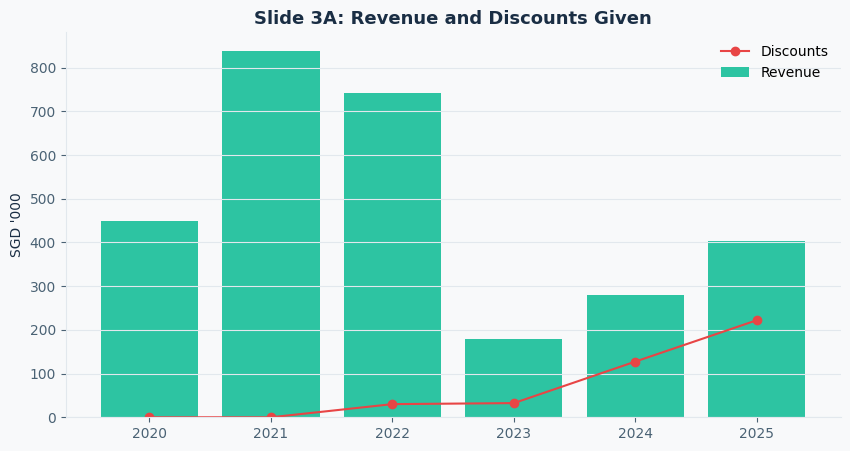

rendered inline: slide3a_revenue_discounts


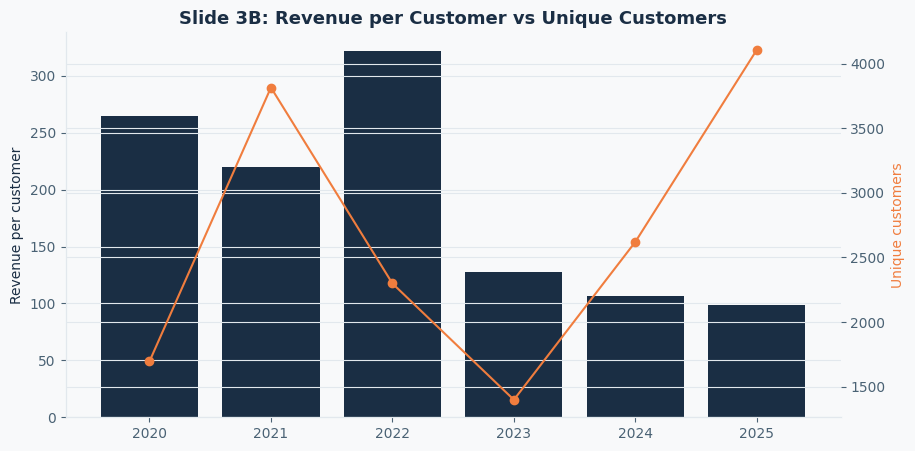

rendered inline: slide3b_customers_rev_per_customer


,chart
0,01a_revenue_discount_trend
1,01b_monthly_revenue_2024_2026
2,01c_orders_customers_by_year
3,02a_retention_by_channel
4,02b_retention_by_product
5,02c_time_to_second_purchase
6,02d_cohort_60d_retention
7,03a_cross_product_ltv
8,03b_product_revenue_mix
9,03c_sku_loyalty


In [5]:
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(a.year.astype(str), a.revenue_sgd/1000, color=TEAL, label="Revenue")
ax.plot(a.year.astype(str), a.discount_sgd/1000, color=RED, marker="o", label="Discounts")
ax.set_title("Slide 3A: Revenue and Discounts Given")
ax.set_ylabel("SGD '000")
ax.legend()
save_chart(fig, "slide3a_revenue_discounts")

fig, ax1 = plt.subplots(figsize=(10,5))
rev_per_customer = a.revenue_sgd / a.customers
ax1.bar(a.year.astype(str), rev_per_customer, color=NAVY)
ax1.set_ylabel("Revenue per customer")
ax2 = ax1.twinx(); ax2.plot(a.year.astype(str), a.customers, color=ORANGE, marker="o"); ax2.set_ylabel("Unique customers", color=ORANGE)
ax1.set_title("Slide 3B: Revenue per Customer vs Unique Customers")
save_chart(fig, "slide3b_customers_rev_per_customer")

chart_index = pd.DataFrame({"chart": RECREATED_CHARTS})
display(chart_index)
chart_index.to_csv(NB_OUT / "05_chart_index.csv", index=False)
